Dataset loaded successfully!

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Shape of dataset:
(303, 14)

Column names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       i

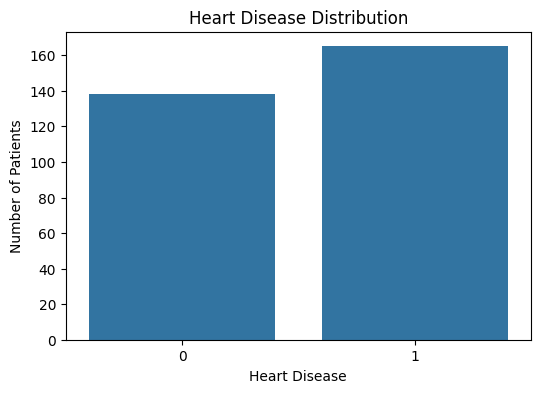

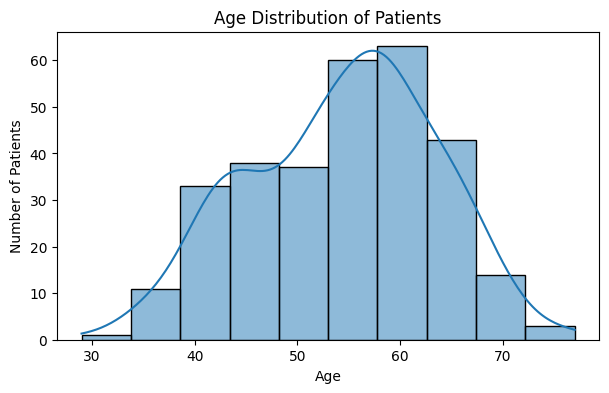

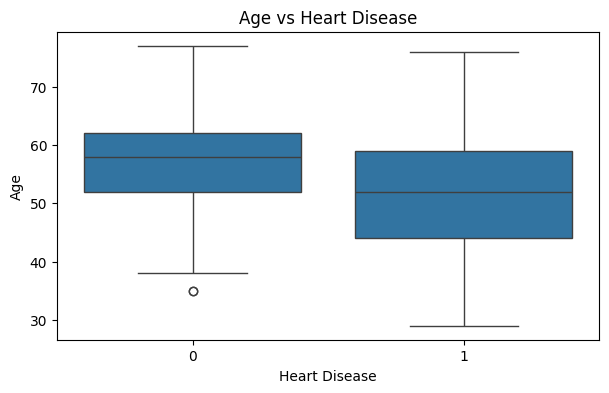

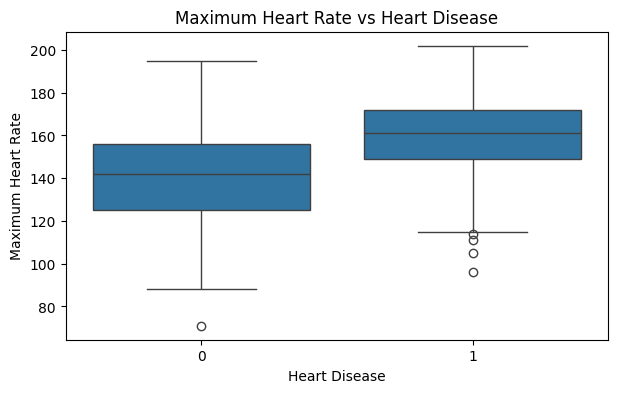

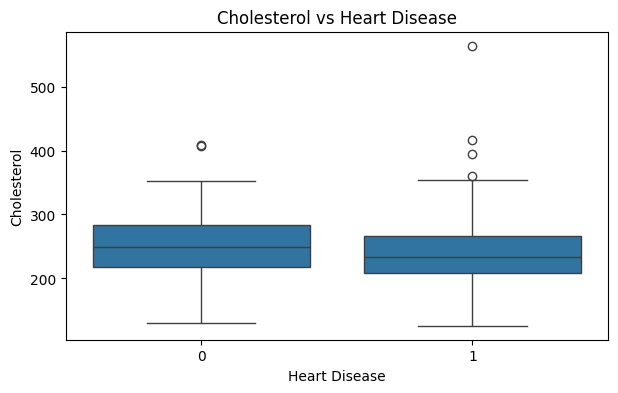

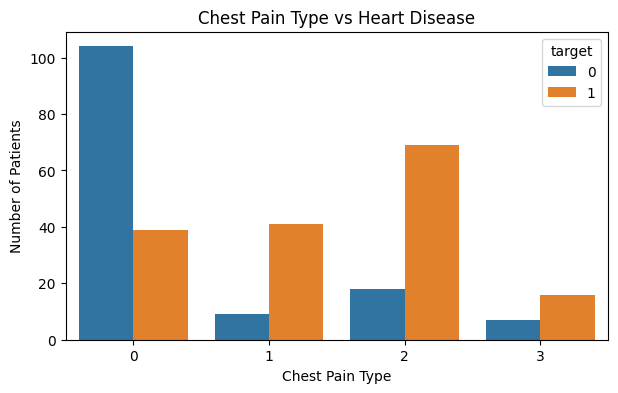

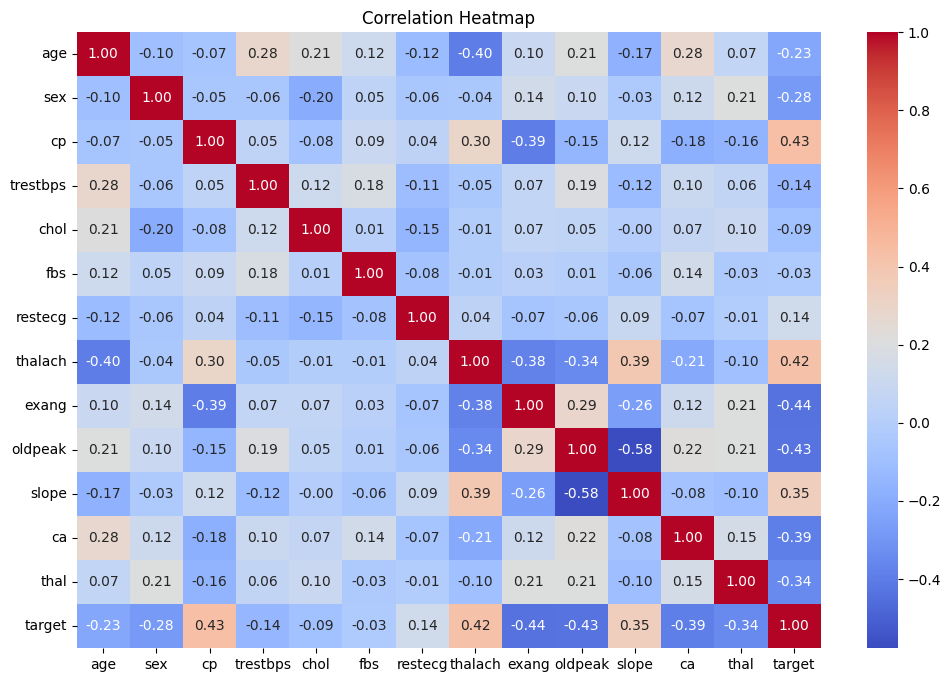


Features:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  
0   0     1  
1   0     2  
2   0     2  
3   0     2  
4   0     2  

Target:
0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

Training data size: (242, 13)
Testing data size: (61, 13)

Model training completed!

Predictions:
[0 0 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0
 1 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0]

       MODEL EVALUATION
Accuracy  : 0.75
Precision : 0.84
Recall    : 0.66
F1 Score  : 0.74

Confusion Matrix:
[[25  4]
 

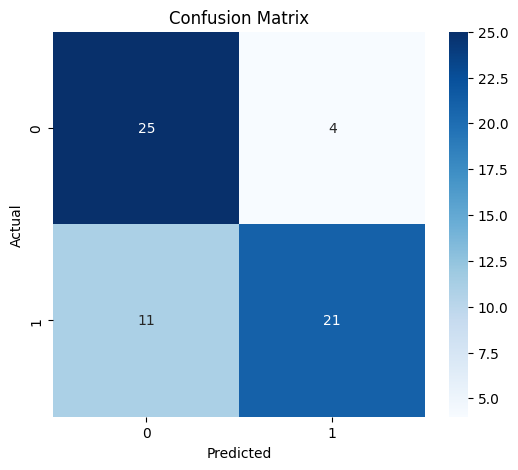

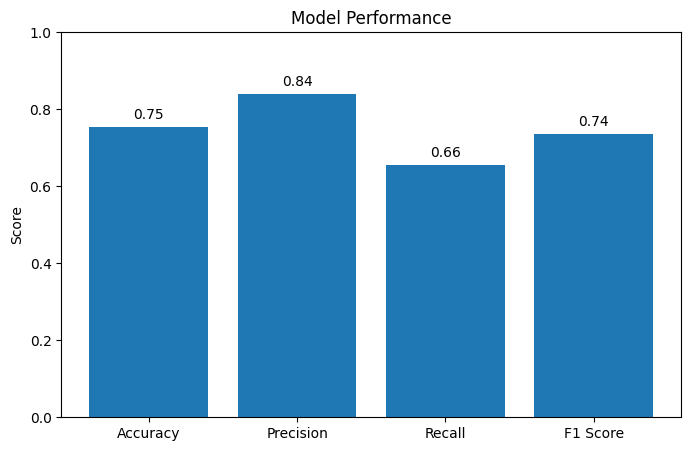

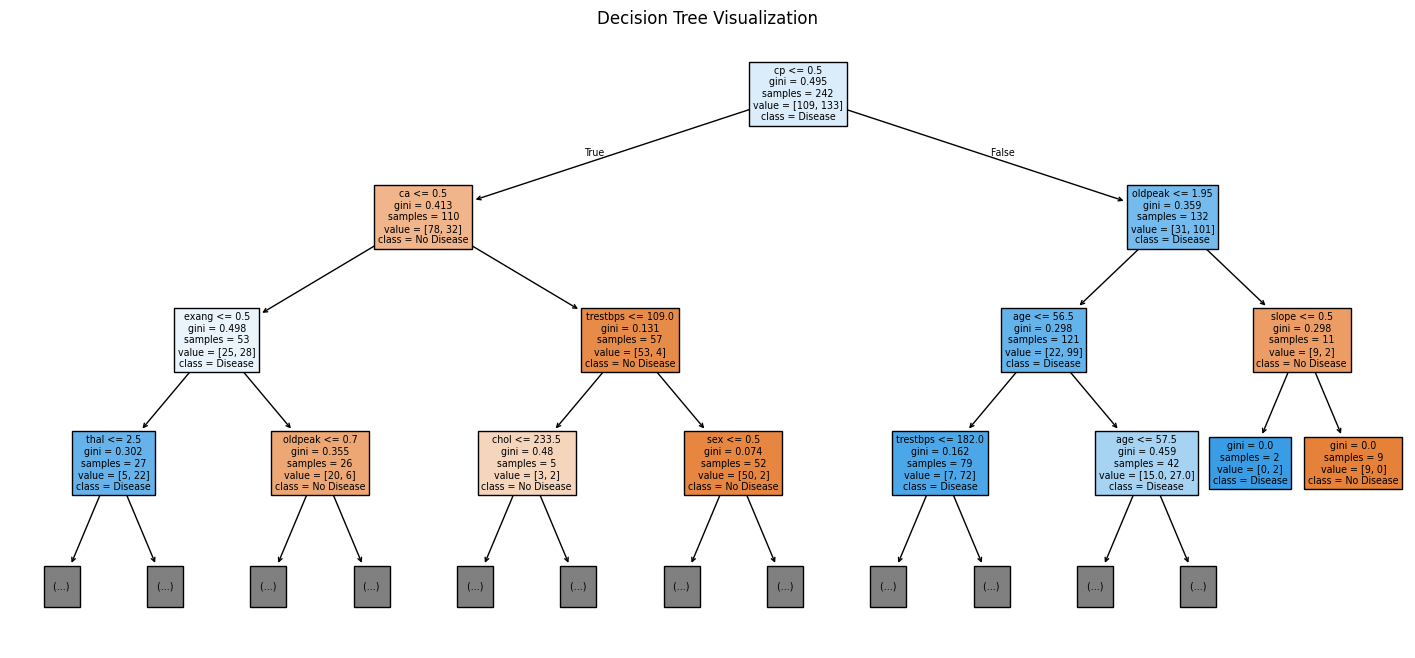


           FINAL RESULTS
Dataset size       : (303, 14)
Training samples   : 242
Testing samples    : 61
Accuracy            : 0.75
Precision           : 0.84
Recall              : 0.66
F1 Score            : 0.74


In [5]:
# HEART DISEASE PREDICTION USING SUPERVISED LEARNING

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

df = pd.read_csv("heart.csv")
print("Dataset loaded successfully!\n")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())


print("\nTarget value counts:")
print(df["target"].value_counts())

plt.figure(figsize=(6, 4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()


# ------------------------------------------------------------
# 7. AGE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

sns.histplot(df["age"], bins=10, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()


# ------------------------------------------------------------
# 8. AGE VS HEART DISEASE
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()


# ------------------------------------------------------------
# 9. MAXIMUM HEART RATE VS HEART DISEASE
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

sns.boxplot(x="target", y="thalach", data=df)

plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")

plt.show()


# ------------------------------------------------------------
# 10. CHOLESTEROL VS HEART DISEASE
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

sns.boxplot(x="target", y="chol", data=df)

plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")

plt.show()


# ------------------------------------------------------------
# 11. CHEST PAIN TYPE VS HEART DISEASE
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

sns.countplot(x="cp", hue="target", data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.show()


# ------------------------------------------------------------
# 12. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# ------------------------------------------------------------
# 13. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop("target", axis=1)
y = df["target"]

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())


# ------------------------------------------------------------
# 14. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data size:", X_train.shape)
print("Testing data size:", X_test.shape)


# ------------------------------------------------------------
# 15. CREATE THE CLASSIFIER
# ------------------------------------------------------------

model = DecisionTreeClassifier(random_state=42)


# ------------------------------------------------------------
# 16. TRAIN THE MODEL
# ------------------------------------------------------------

model.fit(X_train, y_train)

print("\nModel training completed!")


# ------------------------------------------------------------
# 17. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)


# ============================================================
# MODEL EVALUATION
# ============================================================


# ------------------------------------------------------------
# 18. CALCULATE EVALUATION METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)


print("\n====================================")
print("       MODEL EVALUATION")
print("====================================")

print("Accuracy  :", round(accuracy, 2))
print("Precision :", round(precision, 2))
print("Recall    :", round(recall, 2))
print("F1 Score  :", round(f1, 2))


# ------------------------------------------------------------
# 19. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ------------------------------------------------------------
# 20. PERFORMANCE METRICS GRAPH
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

scores = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, scores)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance")

for bar, score in zip(bars, scores):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.2f}",
        ha="center"
    )

plt.show()


# ------------------------------------------------------------
# 21. VISUALIZE THE DECISION TREE
# ------------------------------------------------------------

plt.figure(figsize=(18, 8))

plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    max_depth=3
)

plt.title("Decision Tree Visualization")

plt.show()


# ------------------------------------------------------------
# 22. FINAL SUMMARY
# ------------------------------------------------------------

print("\n====================================")
print("           FINAL RESULTS")
print("====================================")

print("Dataset size       :", df.shape)
print("Training samples   :", len(X_train))
print("Testing samples    :", len(X_test))
print("Accuracy            :", round(accuracy, 2))
print("Precision           :", round(precision, 2))
print("Recall              :", round(recall, 2))
print("F1 Score            :", round(f1, 2))